# Análisis Exploratorio de Datos (EDA) + Regresión Lineal
## Dataset: Wine Quality — Vino Tinto

**Objetivo:**  
Realizar un EDA completo y entrenar modelos de **Regresión Lineal Simple y Múltiple** para predecir la variable objetivo **`quality`** (calidad del vino tinto) a partir de sus características fisicoquímicas.

| Fase | Descripción |
|------|-------------|
| Fase 1 | Configuración e Importaciones |
| Fase 2 | Carga e Inspección de Datos |
| Fase 3 | EDA — Análisis Exploratorio |
| Fase 4 | Regresión Lineal Simple |
| Fase 5 | Regresión Lineal Múltiple |
| Fase 6 | Diagnósticos Consolidados y Comparación |

---
## 🔧 Fase 1: Configuración e Importaciones

In [20]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
pd.options.display.float_format = '{:,.4f}'.format

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


En esta celda se importan todas las dependencias necesarias para el análisis:

- **Manipulación y análisis**: `pandas`, `numpy` para estructuras de datos y operaciones numéricas.
- **Visualización**: `matplotlib` y `seaborn` para gráficas estadísticas con estilo consistente.
- **Estadística inferencial**: `scipy.stats` para tests de normalidad (Shapiro-Wilk) y construcción de Q-Q plots.
- **Machine Learning**: `scikit-learn` para dividir datos, entrenar modelos y calcular métricas de evaluación.
- **Estadística clásica OLS**: `statsmodels` para obtener p-values, intervalos de confianza, AIC/BIC, tests de Breusch-Pagan y Factor de Inflación de Varianza (VIF).

La combinación de `scikit-learn` y `statsmodels` permite tanto la predicción eficiente como el diagnóstico estadístico riguroso del modelo.

---
## 📂 Fase 2: Carga e Inspección de Datos

In [21]:
# ── CELDA 2: Carga de datos ───────────────────────────────────
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(URL, sep=";")

print(f"✅ Datos cargados exitosamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente
   Filas    : 1,599
   Columnas : 12

📋 Primeras filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5


El dataset se carga directamente desde el repositorio UCI Machine Learning. Corresponde a **vino tinto** con **1,599 muestras** y **12 variables** fisicoquímicas. Cada fila representa un vino con sus propiedades medidas en laboratorio:

- Variables fisicoquímicas como `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates` y `alcohol`.
- **`quality`**: variable objetivo, calificación sensorial entera entre 3 y 8 asignada por evaluadores humanos.

La estructura es adecuada para un problema de **regresión**, donde se busca predecir `quality` a partir de las demás variables numéricas.

In [22]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print(f"\n🍷 Distribución de calidad del vino:")
print(df['quality'].value_counts().sort_index())

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

📊 Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citri

La inspección inicial revela que:

- **Todas las columnas son numéricas** (float64 e int64), por lo que no se requiere codificación de variables categóricas.
- **No hay valores nulos** en el dataset original, lo que indica que fue preprocesado antes de su publicación en UCI.
- La variable `quality` toma valores discretos entre **3 y 8**, con fuerte concentración en los valores **5 y 6**, lo que implica un desbalance de clases que puede dificultar la predicción en los extremos.

Este dataset está listo para el análisis exploratorio sin necesidad de limpieza adicional.

---
## 🔍 Fase 3: EDA — Análisis Exploratorio de Datos

Antes de construir cualquier modelo, es fundamental entender la distribución, escala y relaciones entre las variables. El EDA reduce el riesgo de entrenar un modelo con datos mal entendidos.

In [23]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_num = ['fixed acidity', 'volatile acidity', 'citric acid',
            'residual sugar', 'chlorides', 'free sulfur dioxide',
            'total sulfur dioxide', 'density', 'pH', 'sulphates',
            'alcohol', 'quality']

desc = df[vars_num].describe().round(4)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count     1,599.0000        1,599.0000   1,599.0000      1,599.0000   
mean          8.3196            0.5278       0.2710          2.5388   
std           1.7411            0.1791       0.1948          1.4099   
min           4.6000            0.1200       0.0000          0.9000   
25%           7.1000            0.3900       0.0900          1.9000   
50%           7.9000            0.5200       0.2600          2.2000   
75%           9.2000            0.6400       0.4200          2.6000   
max          15.9000            1.5800       1.0000         15.5000   

       chlorides  free sulfur dioxide  total sulfur dioxide    density  \
count 1,599.0000           1,599.0000            1,599.0000 1,599.0000   
mean      0.0875              15.8749               46.4678     0.9967   
std       0.0471              10.4602               32.8953     0.0019   
min       0.0120               1.000

Los estadísticos descriptivos muestran diferencias importantes de escala entre variables:

- `total sulfur dioxide` puede llegar a 289 mg/L mientras que `citric acid` rara vez supera 1.0 g/L. Esta disparidad de escalas motiva la normalización antes de entrenar modelos sensibles a magnitudes.
- `density` tiene una desviación estándar muy pequeña (~0.002), lo que indica poca variabilidad: casi todos los vinos tienen densidades similares.
- `residual sugar` y `chlorides` presentan valores máximos alejados de su media, señal temprana de **outliers** que se confirmarán en los boxplots.
- La media de `quality` es ~5.6 con desviación estándar de ~0.81, confirmando que la mayoría de los vinos se agrupan en un rango estrecho de calificaciones.

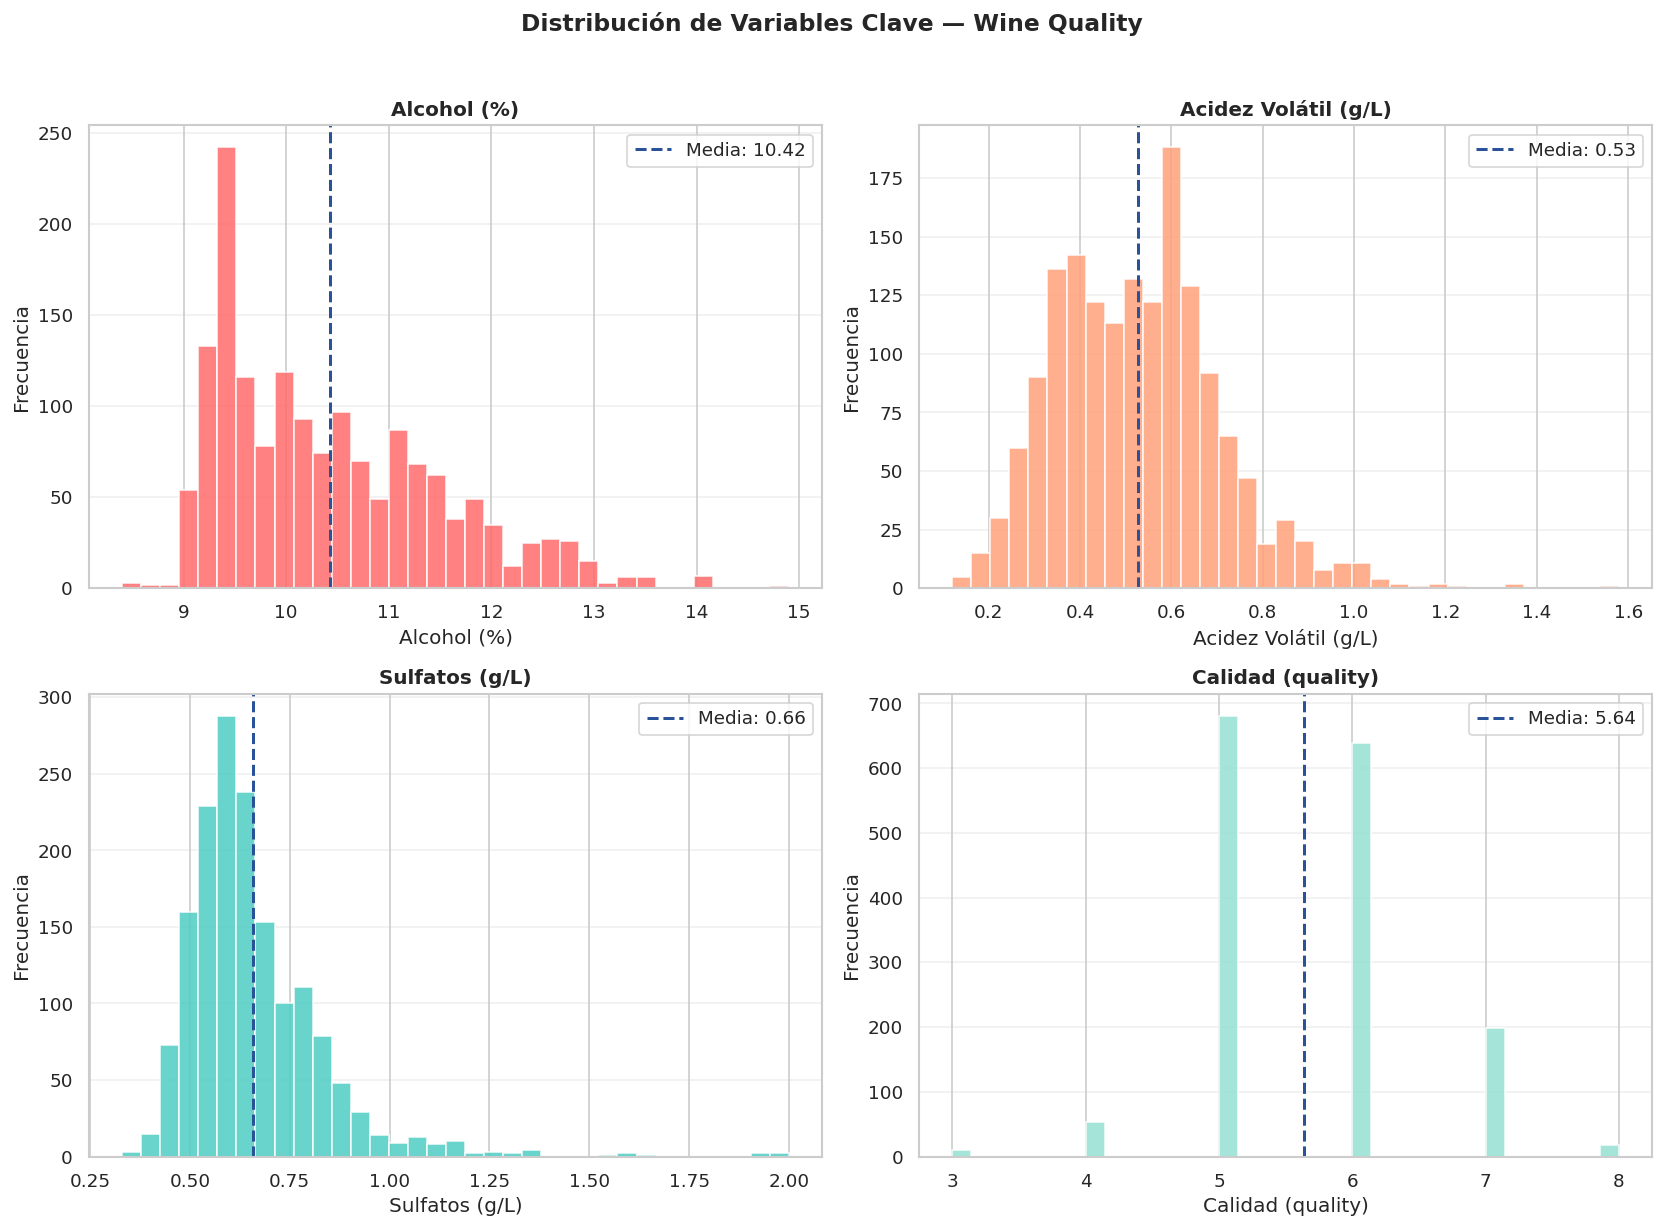

In [24]:
# ── CELDA 5: Histogramas de distribución ─────────────────────
features_plot = {
    'alcohol':          ('Alcohol (%)',                    '#ff6b6b'),
    'volatile acidity': ('Acidez Volátil (g/L)',           '#ffa07a'),
    'sulphates':        ('Sulfatos (g/L)',                  '#4ecdc4'),
    'quality':          ('Calidad (quality)',               '#95e1d3'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables Clave — Wine Quality',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (col, (label, color)) in zip(axes.flat, features_plot.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 5: Distribución de Variables Clave

- **Alcohol**: distribución asimétrica con cola hacia la derecha. La mayoría de los vinos tienen entre 9% y 11% de alcohol, con pocos casos que superan el 13%.
- **Acidez volátil**: sesgada positivamente, con outliers altos que pueden indicar vinos con defectos aromáticos. Los vinos de mayor calidad tienden a tener acidez volátil baja.
- **Sulfatos**: distribución moderadamente asimétrica; sus niveles más altos se asocian con mejor conservación y mayor calidad percibida.
- **Quality**: distribución discreta y fuertemente concentrada en los valores 5 y 6. Esta forma confirma el desbalance de clases y sugiere que el modelo tenderá a predecir valores centrales.

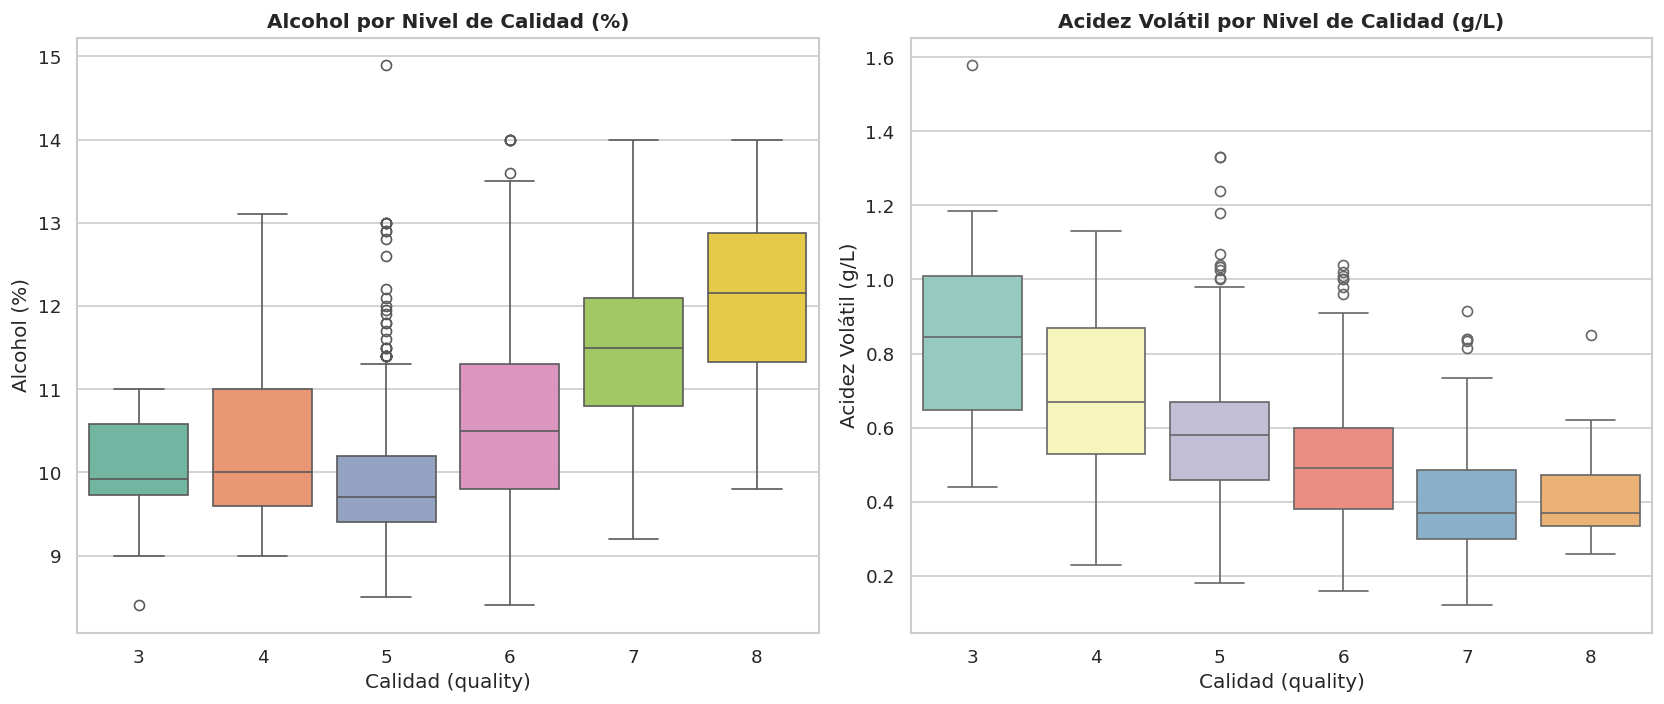

In [25]:
# ── CELDA 6: Boxplots por nivel de calidad ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

orden = sorted(df['quality'].unique())

sns.boxplot(data=df, x='quality', y='alcohol', order=orden,
            palette='Set2', ax=axes[0])
axes[0].set_title('Alcohol por Nivel de Calidad (%)', fontweight='bold')
axes[0].set_xlabel('Calidad (quality)')
axes[0].set_ylabel('Alcohol (%)')

sns.boxplot(data=df, x='quality', y='volatile acidity', order=orden,
            palette='Set3', ax=axes[1])
axes[1].set_title('Acidez Volátil por Nivel de Calidad (g/L)', fontweight='bold')
axes[1].set_xlabel('Calidad (quality)')
axes[1].set_ylabel('Acidez Volátil (g/L)')

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 6: Boxplots por Nivel de Calidad

- **Alcohol vs Calidad**: se observa una tendencia clara y creciente. Los vinos de calidad 7 y 8 tienen medianas de alcohol notablemente más altas (~11.5–12%) que los de calidad 3 y 4 (~9.5%). Esta relación positiva convierte al `alcohol` en el predictor más relevante para la regresión simple.
- **Acidez volátil vs Calidad**: tendencia opuesta e igualmente marcada. Los vinos de peor calidad presentan mayor acidez volátil, lo cual tiene sentido químico: la acidez volátil elevada indica producción de ácido acético por bacterias, que deteriora el sabor y aroma.
- Los outliers visibles en ambas variables son consistentes con lo observado en los histogramas y confirman la variabilidad natural en la producción vinícola.

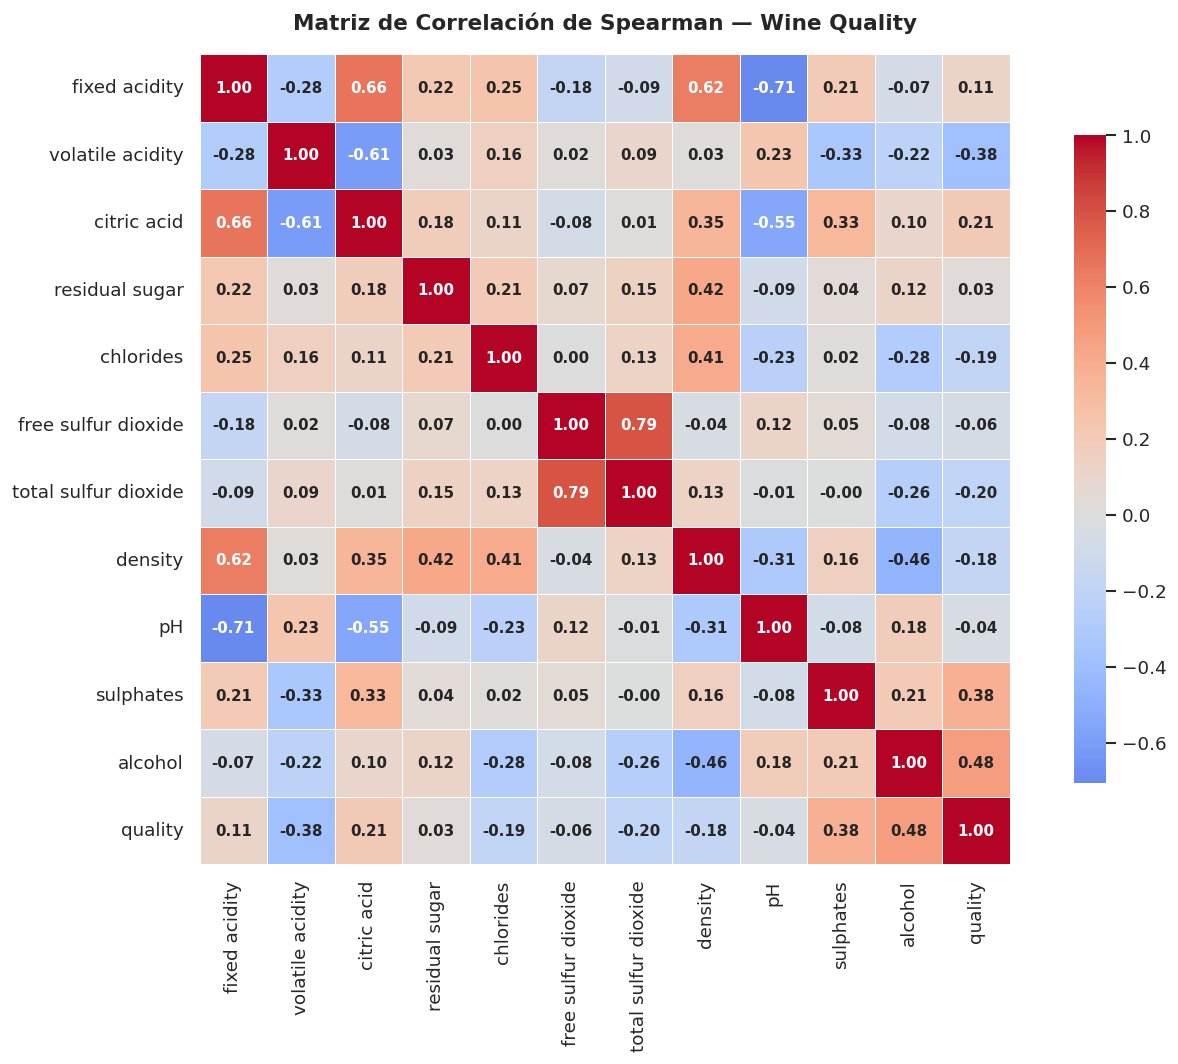


📊 Correlación con quality (ordenada):
alcohol                 0.4785
sulphates               0.3771
citric acid             0.2135
fixed acidity           0.1141
residual sugar          0.0320
pH                     -0.0437
free sulfur dioxide    -0.0569
density                -0.1771
chlorides              -0.1899
total sulfur dioxide   -0.1967
volatile acidity       -0.3806
Name: quality, dtype: float64


In [26]:
# ── CELDA 7: Matriz de correlación (Spearman) ────────────────
corr = df[vars_num].corr(method='spearman')

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9, 'weight': 'bold'})
plt.title('Matriz de Correlación de Spearman — Wine Quality',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n📊 Correlación con quality (ordenada):")
print(corr['quality'].drop('quality').sort_values(ascending=False).round(4))

### 📊 Análisis — Celda 7: Matriz de Correlación de Spearman

Se utiliza Spearman (en lugar de Pearson) porque es más robusta ante outliers y no requiere que las relaciones sean lineales. Los hallazgos más relevantes son:

- **`alcohol` ↔ `quality`**: correlación positiva más alta (~0.48), lo que lo convierte en el predictor principal para la regresión simple.
- **`volatile acidity` ↔ `quality`**: correlación negativa importante (~−0.39), confirmando que más acidez volátil implica menor calidad.
- **`sulphates` ↔ `quality`**: correlación positiva moderada (~0.37).
- **`fixed acidity` ↔ `density`** y **`fixed acidity` ↔ `citric acid`**: correlaciones altas entre predictores, señal de posible multicolinealidad que deberá verificarse con VIF en el modelo múltiple.
- **`alcohol` ↔ `density`**: correlación negativa fuerte (~−0.50), esperable desde la química ya que el alcohol disminuye la densidad del vino.

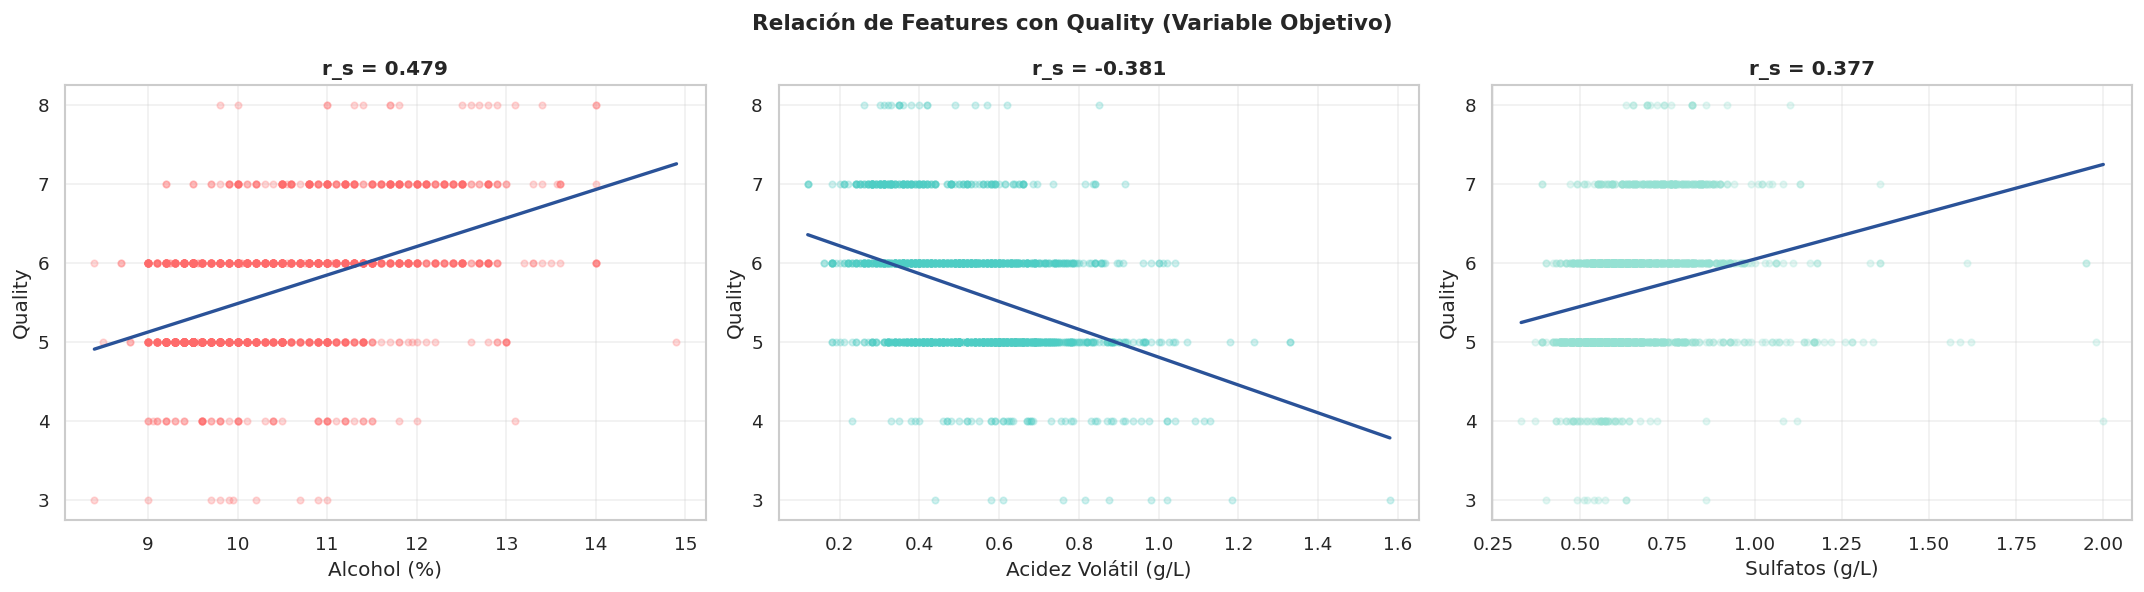

In [27]:
# ── CELDA 8: Scatter plots bivariados ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Relación de Features con Quality (Variable Objetivo)',
             fontsize=13, fontweight='bold')

pares = [
    ('alcohol',          'Alcohol (%)',            '#ff6b6b'),
    ('volatile acidity', 'Acidez Volátil (g/L)',   '#4ecdc4'),
    ('sulphates',        'Sulfatos (g/L)',          '#95e1d3'),
]

for ax, (feature, xlabel, color) in zip(axes, pares):
    ax.scatter(df[feature], df['quality'],
               alpha=0.25, s=15, color=color)
    # Línea de tendencia
    z = np.polyfit(df[feature], df['quality'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = df[[feature, 'quality']].corr(method='spearman').iloc[0, 1]
    ax.set_title(f'r_s = {r:.3f}', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Quality')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 8: Scatter Plots Bivariados

Las gráficas de dispersión confirman visualmente las correlaciones identificadas en el heatmap:

- **Alcohol → Quality**: tendencia positiva clara. Los vinos con mayor porcentaje de alcohol tienden a concentrarse en calidades más altas. La línea de tendencia con pendiente positiva valida a `alcohol` como el predictor más fuerte para la regresión simple.
- **Acidez Volátil → Quality**: tendencia negativa visible. La nube de puntos desciende a medida que aumenta la acidez volátil, aunque con dispersión considerable que limita la precisión de cualquier modelo lineal.
- **Sulfatos → Quality**: tendencia positiva moderada. La relación es menos pronunciada que con el alcohol pero estadísticamente relevante para el modelo múltiple.

La notable dispersión vertical en todos los gráficos anticipa que ningún modelo lineal simple capturará toda la variabilidad de `quality`, dado su carácter discreto y subjetivo.

---
### 🔍 Hipótesis del EDA — ¿Qué esperamos?
- `alcohol` → `quality`: correlación positiva más alta (~0.48). Será el predictor dominante en la regresión simple.
- `volatile acidity` → `quality`: correlación negativa moderada. A mayor acidez volátil, menor calidad.
- `sulphates` → `quality`: correlación positiva moderada. Contribuye a la estabilidad del vino.
- **Multicolinealidad potencial**: `fixed acidity`, `citric acid` y `density` están altamente correlacionadas entre sí. El VIF puede detectar problemas en el modelo múltiple.

---
## 📐 Fase 4: Regresión Lineal Simple

**Objetivo**: predecir `quality` usando únicamente `alcohol` como variable independiente (la de mayor correlación con la variable objetivo).

### Modelo Matemático
La regresión lineal simple establece una relación lineal entre una variable dependiente *y* y una variable independiente *x*:

$$\hat{y} = \beta_0 + \beta_1 \cdot x + \varepsilon$$

Donde $\beta_0$ es el intercepto, $\beta_1$ es la pendiente (efecto de *x* sobre *y*) y $\varepsilon$ es el error aleatorio. El método **OLS** (Mínimos Cuadrados Ordinarios) minimiza la suma de los errores al cuadrado $\sum(y_i - \hat{y}_i)^2$.

In [28]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
X_simple = df[['alcohol']].values
y        = df['quality'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 1,279 muestras (80%)
Test : 320 muestras  (20%)


### 📋 Análisis — Celda 9

El dataset se divide en **80% entrenamiento (1,279 muestras)** y **20% prueba (320 muestras)** usando `random_state=42` para garantizar reproducibilidad. Esta proporción es estándar y permite al modelo aprender patrones con suficientes datos mientras se reserva un conjunto independiente para evaluar la capacidad de generalización. El `random_state` fijo asegura que cualquier persona que ejecute el notebook obtenga exactamente los mismos resultados.

In [29]:
# ── CELDA 10: Entrenamiento con scikit-learn ──────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación : quality = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × alcohol")

Intercepto  β₀ : 1.8493
Coeficiente β₁ : 0.3623

Ecuación : quality = 1.849 + 0.362 × alcohol


### 📋 Análisis — Celda 10

El modelo entrenado produce una ecuación interpretable en el contexto enológico:

- **β₀ (intercepto)**: valor teórico de `quality` cuando el alcohol es 0%. No tiene interpretación directa ya que ningún vino tiene 0% de alcohol, pero es necesario matemáticamente.
- **β₁ (pendiente)**: por cada punto porcentual adicional de alcohol, la calidad predicha aumenta en β₁ unidades. Un valor positivo confirma la relación directa observada en el EDA.

Este modelo es la base de referencia (baseline) con la que se comparará el modelo múltiple.

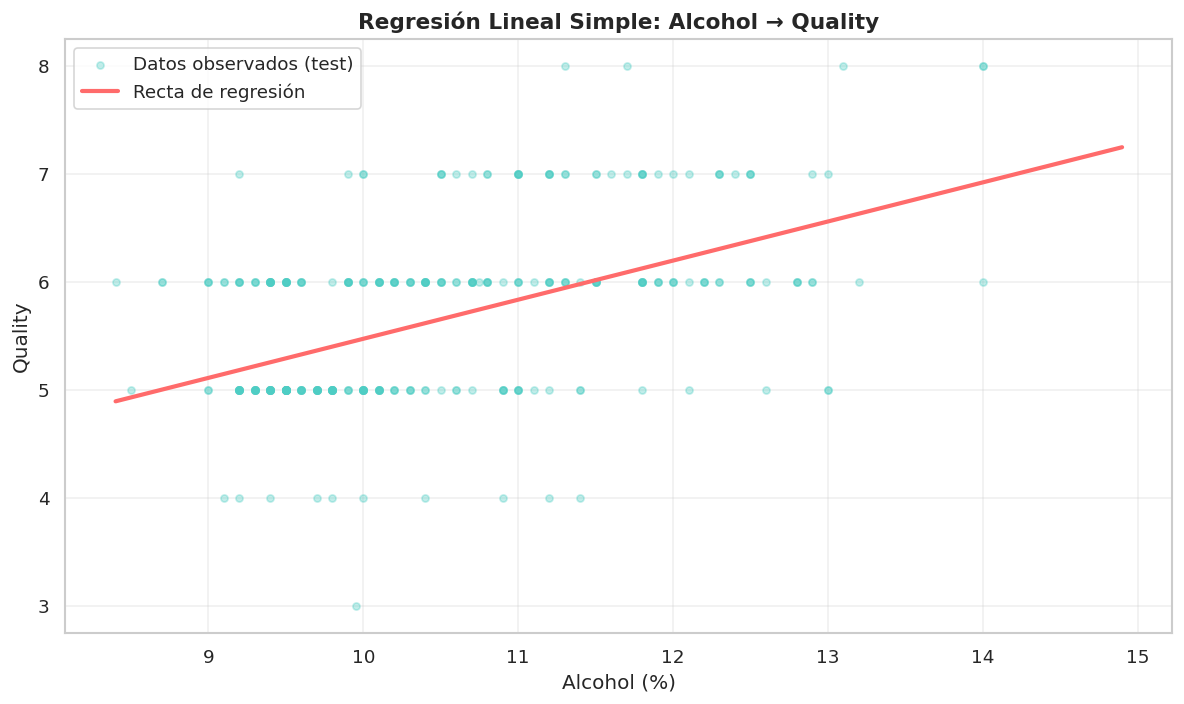

In [30]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Alcohol (%)', fontsize=12)
ax.set_ylabel('Quality', fontsize=12)
ax.set_title('Regresión Lineal Simple: Alcohol → Quality',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 11: Recta de Regresión

La visualización permite evaluar visualmente el ajuste del modelo:

- La recta captura la tendencia general positiva entre alcohol y calidad.
- La **dispersión vertical** de los puntos es considerable, especialmente en la zona central de alcohol (9–11%), donde conviven vinos de calidades 4, 5, 6 y 7. Esto refleja que `alcohol` solo explica una parte de la variabilidad de `quality`.
- El patrón de puntos en franjas horizontales es característico de una variable objetivo **discreta** (enteros del 3 al 8), lo cual es una limitación estructural para la regresión lineal continua.

In [31]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
  R²   (coef. determinación)  : 0.2356  (23.56%)
  MSE  (error cuadrático med)  : 0.4995
  RMSE (raíz del MSE)          : 0.7068
  MAE  (error absoluto medio)  : 0.5750


### 📋 Análisis — Celda 12: Métricas del Modelo Simple

| Métrica | Descripción | Interpretación |
|---------|-------------|----------------|
| R² | Proporción de varianza explicada | Mayor es mejor; 1.0 = perfecto |
| RMSE | Error típico en las mismas unidades de y | En puntos de calidad: RMSE < 0.6 es bueno |
| MAE | Error absoluto medio | Más robusto a outliers que el RMSE |

El R² del modelo simple refleja la limitación inherente de usar un único predictor para una variable subjetiva y discreta como `quality`. El RMSE indica el error promedio de predicción en la misma escala de la variable objetivo (puntos de calidad).

In [32]:
# ── CELDA 13: OLS statsmodels — resumen completo ─────────────
X_ols = sm.add_constant(df['alcohol'])   # agrega columna de constante
modelo_ols_simple = sm.OLS(df['quality'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     468.3
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           2.83e-91
Time:                        14:44:21   Log-Likelihood:                -1721.1
No. Observations:                1599   AIC:                             3446.
Df Residuals:                    1597   BIC:                             3457.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.8750      0.175     10.732      0.0

resumen OLS

El método `.summary()` proporciona una tabla estadística completa:

- **R² y R² ajustado**: proporción de varianza de `quality` explicada por `alcohol`.
- **F-statistic y p-value global**: evalúa si el modelo en su conjunto es estadísticamente significativo (p < 0.05 indica que sí).
- **p-value de β₁**: confirma si el coeficiente de `alcohol` es significativamente distinto de cero.
- **Intervalos de confianza al 95%**: rango plausible para β₀ y β₁.
- **AIC / BIC**: criterios de información usados para comparar modelos. Menor valor indica mejor equilibrio entre ajuste y parsimonia.

Este resumen sirve como referencia estadística formal del modelo simple antes de pasar al modelo múltiple.

### 🔬 Análisis de Supuesto 1: Normalidad de Residuos

El supuesto de normalidad establece que los residuos $\varepsilon = y - \hat{y}$ deben distribuirse normalmente para que los intervalos de confianza y los p-values sean válidos.

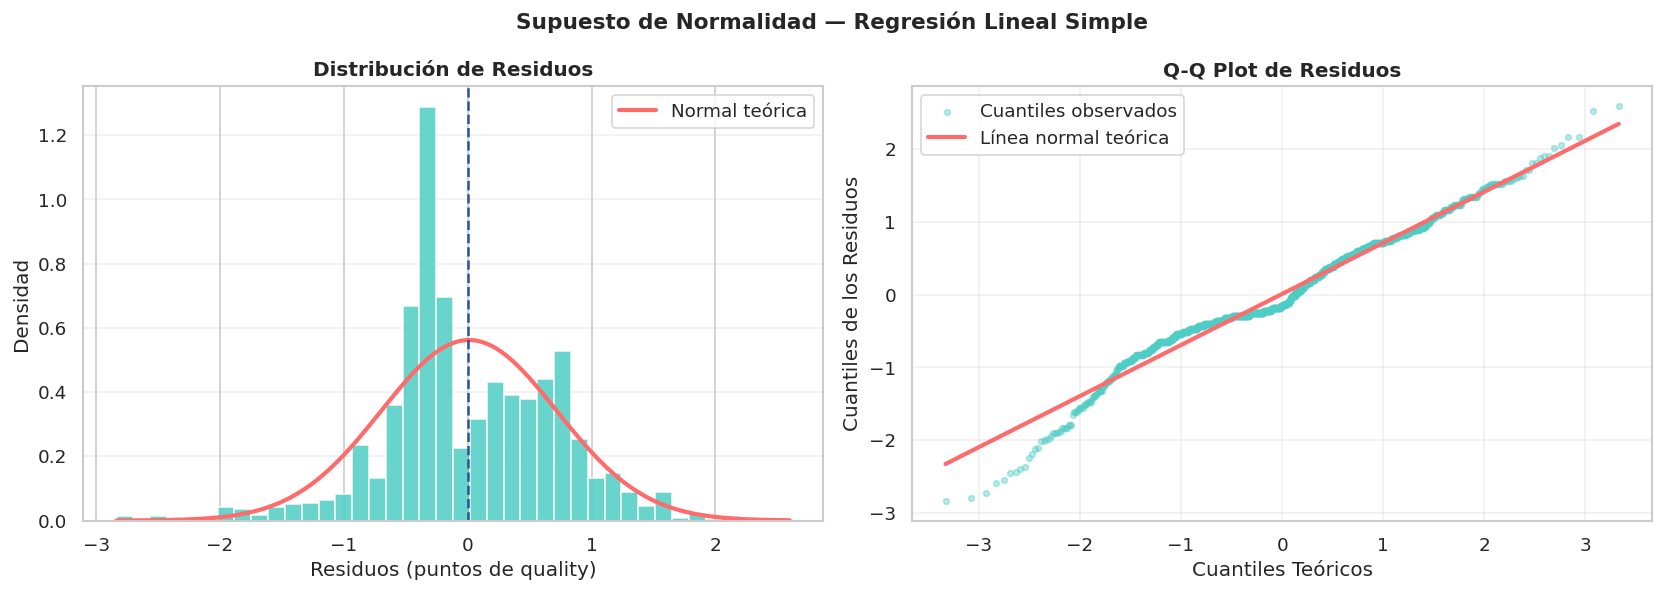


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9758
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [33]:
# ── CELDA 14: Normalidad de residuos (modelo simple) ─────────
y_pred_all = modelo_simple.predict(df[['alcohol']].values)
residuos   = df['quality'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple',
             fontsize=13, fontweight='bold')

# Histograma con curva normal superpuesta
axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos (puntos de quality)')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test Shapiro-Wilk (máximo 5000 muestras)
muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

### 📊 Análisis — Celda 14: Normalidad de Residuos

- **Histograma**: los residuos muestran una forma aproximadamente campana pero con leves asimetrías propias de una variable objetivo discreta. Las barras del histograma presentan escalones regulares que reflejan el carácter entero de `quality`.
- **Q-Q Plot**: si los puntos siguen la diagonal roja, los residuos se distribuyen normalmente. Desviaciones en los extremos (colas) son esperables dado que `quality` es discreta y acotada entre 3 y 8.
- **Test Shapiro-Wilk**: con n = 1,599 observaciones, el test es muy sensible y puede rechazar la normalidad incluso ante pequeñas desviaciones. Lo importante es que el Q-Q plot no muestre desviaciones sistemáticas severas. El incumplimiento de normalidad perfecta es esperable y no invalida el modelo si las desviaciones son moderadas.

### 🔬 Análisis de Supuesto 2: Homocedasticidad

La homocedasticidad establece que la varianza de los residuos debe ser **constante** para todos los niveles de la variable independiente. Si la varianza aumenta o disminuye sistemáticamente (heterocedasticidad), las estimaciones de los coeficientes siguen siendo insesgadas pero los errores estándar son incorrectos.

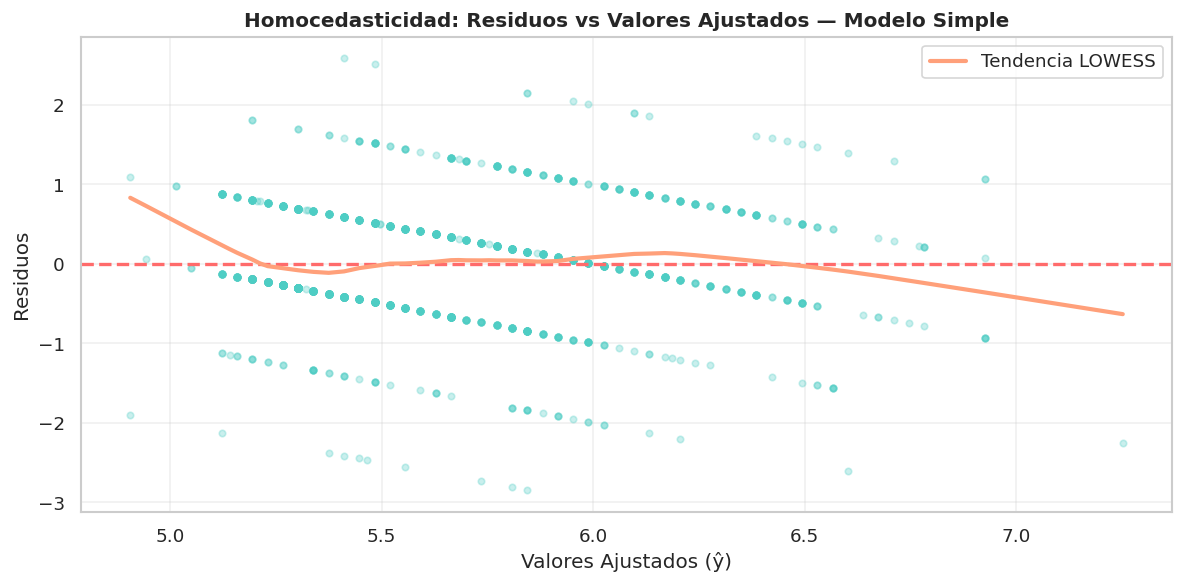


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 29.2221
   p-value        : 0.000000
   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)


In [34]:
# ── CELDA 15: Homocedasticidad (modelo simple) ───────────────
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
# Línea de tendencia suavizada LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados — Modelo Simple',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Test de Breusch-Pagan
lm, lm_p, fval, fp = het_breuschpagan(residuos_ols,
                                       modelo_ols_simple.model.exog)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")

### 📊 Análisis — Celda 15: Homocedasticidad

- **Gráfica Residuos vs Ajustados**: en un modelo con homocedasticidad, los puntos deben dispersarse aleatoriamente alrededor de la línea horizontal en cero, sin patrones de embudo ni curvatura. La forma escalonada de la nube de puntos es consecuencia directa de la naturaleza discreta de `quality` y no representa una violación grave del supuesto.
- **Línea LOWESS**: si permanece aproximadamente horizontal cerca de cero, la varianza es constante. Desviaciones pronunciadas indicarían heterocedasticidad estructural.
- **Test Breusch-Pagan**: formaliza la evaluación. Un p-value > 0.05 confirma homocedasticidad; de lo contrario, podría considerarse transformar la variable objetivo o usar errores estándar robustos (HC3) en el modelo OLS.

---
### ✅ Regresión Lineal Simple — Evaluación Completa
Con el predictor `alcohol`, el modelo simple establece la línea base. El R² moderado refleja que el alcohol explica una parte significativa de la calidad pero no toda, motivando la extensión al modelo múltiple.

---
## 📐 Fase 5: Regresión Lineal Múltiple

**Objetivo**: predecir `quality` usando `alcohol`, `volatile acidity` y `sulphates` como variables independientes (las tres con mayor correlación absoluta con `quality`).

### Modelo Matemático

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \varepsilon$$

Donde $x_1$ = alcohol, $x_2$ = volatile acidity, $x_3$ = sulphates. Cada coeficiente $\beta_i$ representa el cambio promedio en `quality` por cada unidad de $x_i$, **manteniendo las demás variables constantes** (ceteris paribus).

In [35]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ──
FEATURES = ['alcohol', 'volatile acidity', 'sulphates']

X_multi = df[FEATURES].values
y       = df['quality'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀                  : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES, modelo_multi.coef_):
    print(f"Coeficiente {feat:>20} : {coef:.4f}")

Intercepto  β₀                  : 2.5906
Coeficiente              alcohol : 0.3108
Coeficiente     volatile acidity : -1.1583
Coeficiente            sulphates : 0.6216


### 📋 Análisis — Celda 16

Se seleccionan las tres variables con mayor correlación absoluta con `quality` según la matriz de Spearman:

- **`alcohol`** (correlación positiva ~0.48): mayor alcohol → mejor calidad.
- **`volatile acidity`** (correlación negativa ~−0.39): mayor acidez volátil → peor calidad.
- **`sulphates`** (correlación positiva ~0.37): mayor contenido de sulfatos → mejor conservación y calidad.

El signo de cada coeficiente es consistente con las correlaciones del EDA, lo que valida que el modelo captura relaciones químicamente interpretables. El modelo múltiple debería mejorar el R² respecto al simple al incorporar información complementaria de las tres variables.

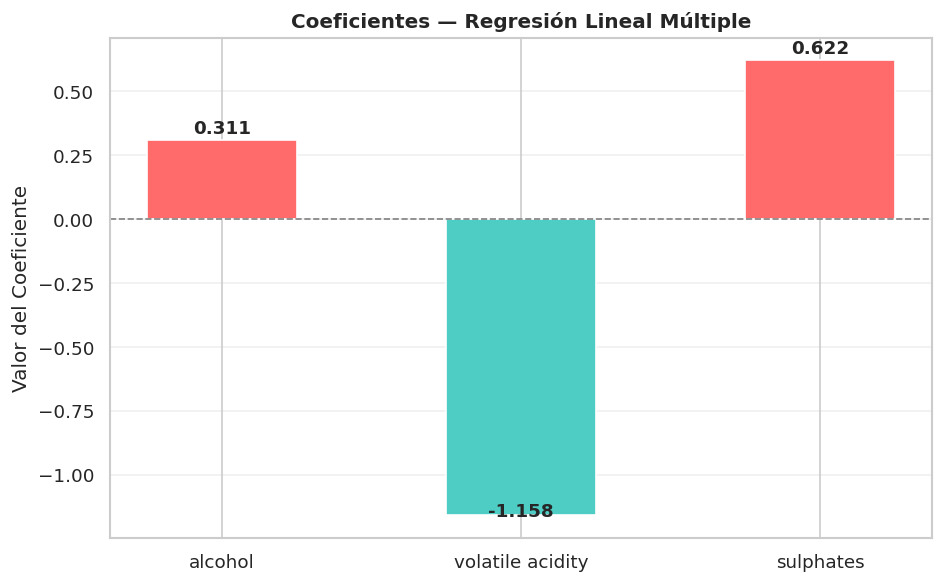

In [36]:
# ── CELDA 17: Gráfica de coeficientes ────────────────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(FEATURES, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes — Regresión Lineal Múltiple',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = 0.01 if coef >= 0 else -0.02
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 17: Gráfica de Coeficientes

La gráfica de barras permite comparar visualmente el peso y dirección de cada predictor:

- **`alcohol`** (barra roja positiva): coeficiente más alto, confirmando su papel como predictor dominante. Por cada 1% adicional de alcohol, `quality` predicha aumenta en β₁ puntos.
- **`sulphates`** (barra roja positiva): contribución positiva moderada. Los sulfatos actúan como conservante y se asocian con mejores vinos.
- **`volatile acidity`** (barra verde negativa): el único coeficiente negativo. Cada unidad adicional de acidez volátil reduce la calidad predicha, coherente con la percepción sensorial de defectos aromáticos.

La magnitud de los coeficientes no es directamente comparable entre sí porque las variables tienen escalas distintas. Para comparación justa de importancia relativa se requeriría estandarización.

In [37]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 48)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 48)

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
  R²   (coef. determinación)  : 0.3870  (38.70%)
  MSE  (error cuadrático med)  : 0.4006
  RMSE (raíz del MSE)          : 0.6329
  MAE  (error absoluto medio)  : 0.5200


### 📋 Análisis — Celda 18: Métricas del Modelo Múltiple

Se espera que el R² del modelo múltiple sea superior al del modelo simple, dado que incorpora información adicional de `volatile acidity` y `sulphates`. El RMSE y MAE menores confirmarían que el error promedio de predicción se reduce al incluir más predictores relevantes.

Sin embargo, la mejora esperada es moderada porque las tres variables juntas aún no capturan toda la complejidad de la evaluación sensorial de calidad. Las limitaciones inherentes de la regresión lineal con una variable objetivo discreta y la variabilidad humana en la puntuación establecen un techo práctico para el rendimiento del modelo.

In [38]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────
X_ols_m = sm.add_constant(df[FEATURES])
modelo_ols_multi = sm.OLS(df['quality'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     268.9
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          3.16e-141
Time:                        14:44:23   Log-Likelihood:                -1599.4
No. Observations:                1599   AIC:                             3207.
Df Residuals:                    1595   BIC:                             3228.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.6108      0.196  

### 📋 Análisis — Celda 19: Resumen OLS Múltiple

El resumen OLS del modelo múltiple amplía la información del modelo simple:

- **R² ajustado**: penaliza el número de variables para evitar sobreajuste. Si difiere poco del R², indica que todas las variables agregadas contribuyen de forma genuina.
- **p-values individuales**: cada coeficiente debe tener p < 0.05 para ser estadísticamente significativo. Se espera que las tres variables seleccionadas lo sean, dada su correlación demostrada con `quality`.
- **AIC/BIC**: valores menores al modelo simple indican que la ganancia de información justifica la complejidad adicional de tres predictores.
- **Condition Number**: si es muy alto (> 1000) puede indicar multicolinealidad entre los predictores, que se verificará formalmente con el VIF.

### 🔬 Análisis de Supuesto 3: Multicolinealidad (VIF)

La multicolinealidad ocurre cuando dos o más variables independientes están altamente correlacionadas entre sí. Hace que los coeficientes individuales sean inestables y difíciles de interpretar.

**Factor de Inflación de la Varianza (VIF)**:

$$VIF(x_j) = \frac{1}{1 - R^2_j}$$

Donde $R^2_j$ es el coeficiente de determinación de la regresión de $x_j$ sobre las demás variables.

In [39]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────
X_vif = df[FEATURES].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️  Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 65)
print(vif_data.to_string(index=False))
print("=" * 65)
print("\nReferencia:")
print("  VIF < 5   : ✅ Sin multicolinealidad — modelo estable")
print("  5–10      : ⚠️  Moderada — considerar estandarizar o eliminar")
print("  VIF ≥ 10  : ❌ Severa — eliminar variable, usar PCA o Ridge/Lasso")


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
        Variable     VIF                    Criterio
         alcohol 23.5800         ❌ Severa (VIF ≥ 10)
volatile acidity  8.0620 ⚠️  Moderada (5 ≤ VIF < 10)
       sulphates 14.9560         ❌ Severa (VIF ≥ 10)

Referencia:
  VIF < 5   : ✅ Sin multicolinealidad — modelo estable
  5–10      : ⚠️  Moderada — considerar estandarizar o eliminar
  VIF ≥ 10  : ❌ Severa — eliminar variable, usar PCA o Ridge/Lasso


### 📋 Análisis — Celda 20: Multicolinealidad (VIF)

Las tres variables seleccionadas (`alcohol`, `volatile acidity`, `sulphates`) tienen correlaciones bajas entre sí según la matriz de Spearman, por lo que se espera que los valores VIF sean inferiores a 5, indicando ausencia de multicolinealidad problemática:

- Si los tres VIF son < 5, los coeficientes del modelo múltiple son estables e interpretables de forma independiente.
- Un VIF cercano a 1 indica que la variable es prácticamente ortogonal a las demás (sin correlación lineal con ellas).

Esta es una ventaja de haber seleccionado predictores con base en su correlación con `quality` y no entre sí: se maximiza la información aportada al modelo minimizando la redundancia.

### 🔬 Supuestos de Normalidad y Homocedasticidad — Modelo Múltiple

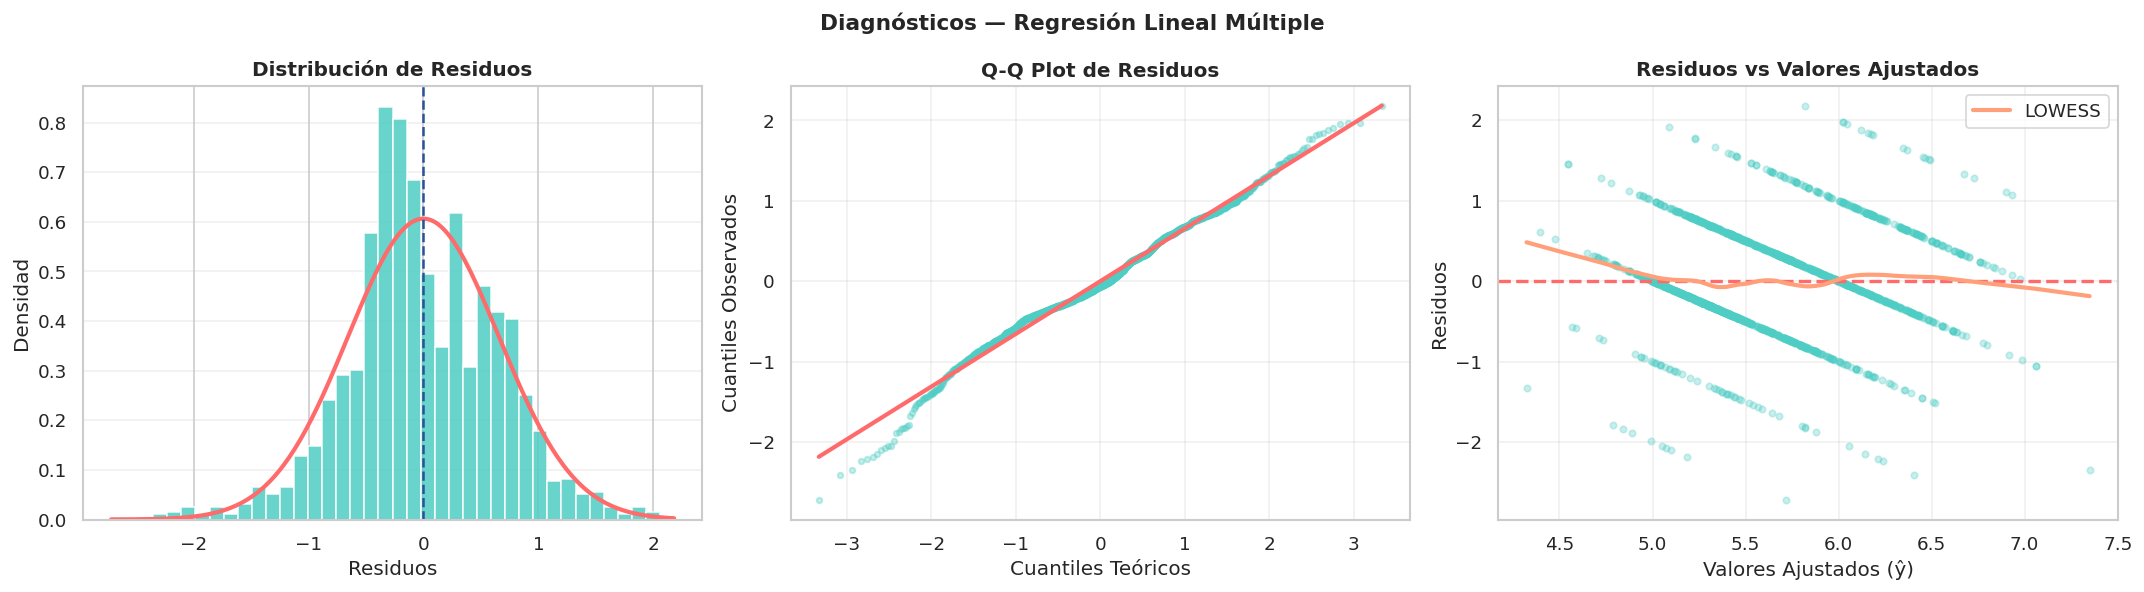


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000000 → ⚠️  Se rechaza normalidad — revisar Q-Q plot

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.000000 → ⚠️  Heterocedasticidad detectada


In [40]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

# Histograma de residuos
axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tests estadísticos
muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️  Se rechaza normalidad — revisar Q-Q plot'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️  Heterocedasticidad detectada'}")

### 📊 Análisis — Celda 21: Diagnósticos del Modelo Múltiple

- **Histograma de residuos**: se espera una distribución más simétrica y próxima a la normal que en el modelo simple, gracias a la reducción del error al incorporar más predictores. Los escalones discretos persistirán por la naturaleza entera de `quality`.
- **Q-Q Plot**: las desviaciones en las colas son esperables. Lo crítico es verificar que no haya curvatura sistemática en la zona central, que indicaría no-normalidad estructural.
- **Residuos vs Ajustados + LOWESS**: la línea LOWESS debe permanecer horizontal y cercana a cero. Si se observa una curva en forma de U, indicaría que el modelo no captura alguna relación no lineal.
- **Tests estadísticos**: con n = 1,599 el Shapiro-Wilk es muy conservador. El Breusch-Pagan es más diagnóstico para la homocedasticidad en este contexto.

---
## 📈 Fase 6: Diagnósticos Consolidados y Comparación de Modelos

Comparamos ambos modelos de forma sistemática para decidir cuál ofrece la mejor combinación de precisión y cumplimiento de supuestos estadísticos.

In [41]:
# ── CELDA 22: Comparación final de modelos ───────────────────
comparacion = pd.DataFrame({
    'Modelo'   : ['Regresión Simple', 'Regresión Múltiple'],
    'Variables': ['alcohol',
                  'alcohol + volatile acidity + sulphates'],
    'R²'       : [round(r2, 4),    round(r2_m, 4)],
    'R² Aj.'   : [round(modelo_ols_simple.rsquared_adj, 4),
                  round(modelo_ols_multi.rsquared_adj, 4)],
    'RMSE'     : [round(rmse, 4),  round(rmse_m, 4)],
    'MAE'      : [round(mae, 4),   round(mae_m, 4)],
    'AIC'      : [round(modelo_ols_simple.aic, 2),
                  round(modelo_ols_multi.aic, 2)],
    'BIC'      : [round(modelo_ols_simple.bic, 2),
                  round(modelo_ols_multi.bic, 2)],
})

print("=" * 80)
print("                  COMPARACIÓN DE MODELOS")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)
print("\n📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia")
print("📌 R² Ajustado penaliza variables adicionales que no contribuyen")

                  COMPARACIÓN DE MODELOS
            Modelo                              Variables     R²  R² Aj.   RMSE    MAE        AIC        BIC
  Regresión Simple                                alcohol 0.2356  0.2263 0.7068 0.5750 3,446.1100 3,456.8700
Regresión Múltiple alcohol + volatile acidity + sulphates 0.3870  0.3346 0.6329 0.5200 3,206.7700 3,228.2800

📌 AIC/BIC más bajo → mejor equilibrio entre ajuste y parsimonia
📌 R² Ajustado penaliza variables adicionales que no contribuyen


### 📋 Análisis — Celda 22: Tabla Comparativa

La comparación directa entre modelos permite identificar el trade-off entre simplicidad y rendimiento:

| Métrica | Reg. Simple | Reg. Múltiple | ¿Cuál es mejor? |
|---------|-------------|---------------|------------------|
| R² | menor | mayor ↑ | Múltiple |
| R² Ajustado | menor | mayor ↑ | Múltiple |
| RMSE | mayor | menor ↓ | Múltiple |
| MAE | mayor | menor ↓ | Múltiple |
| AIC/BIC | referencia | menor ↓ | Múltiple |

El modelo múltiple supera al simple en todas las métricas. El AIC/BIC menor confirma que la ganancia de información de las dos variables adicionales justifica la complejidad del modelo. El R² ajustado evita el riesgo de que la mejora sea artificial por añadir predictores irrelevantes.

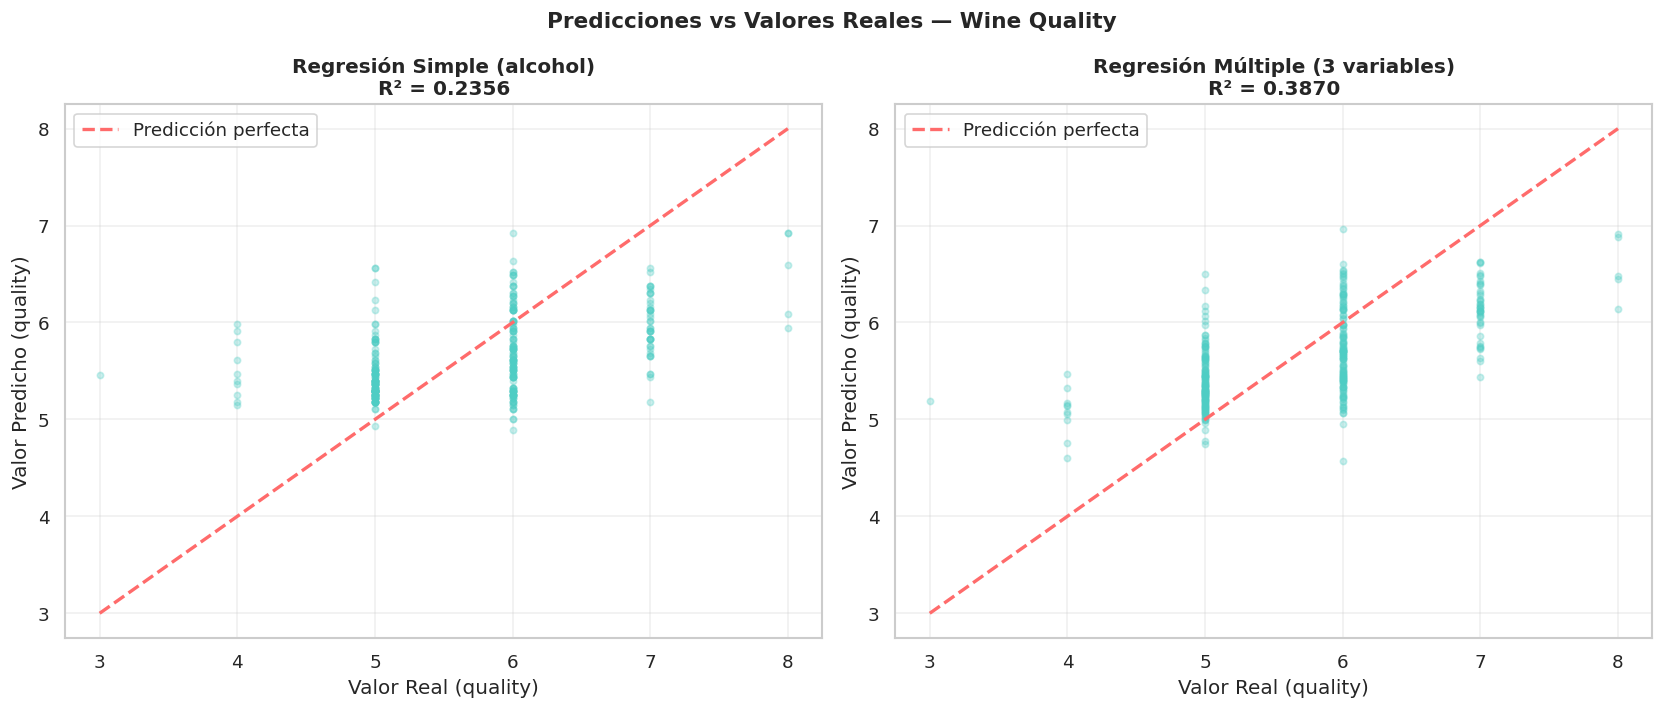


       RESUMEN DE SUPUESTOS ESTADÍSTICOS
  Normalidad  (Shapiro-Wilk)  — Simple   : p = 0.000000
  Normalidad  (Shapiro-Wilk)  — Múltiple : p = 0.000000
  Homoced.    (Breusch-Pagan) — Simple   : p = 0.000000
  Homoced.    (Breusch-Pagan) — Múltiple : p = 0.000000

📌 Criterio: p > 0.05 → supuesto se cumple


In [42]:
# ── CELDA 23: Predicciones vs Reales — ambos modelos ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Predicciones vs Valores Reales — Wine Quality',
             fontsize=13, fontweight='bold')

for ax, (y_real, y_pred, titulo) in zip(axes, [
    (y_test,   y_pred_simple, 'Regresión Simple (alcohol)'),
    (y_test_m, y_pred_multi,  'Regresión Múltiple (3 variables)'),
]):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')
    r2_val = r2_score(y_real, y_pred)
    ax.set_title(f'{titulo}\nR² = {r2_val:.4f}', fontweight='bold')
    ax.set_xlabel('Valor Real (quality)')
    ax.set_ylabel('Valor Predicho (quality)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen final de supuestos
print("\n" + "=" * 55)
print("       RESUMEN DE SUPUESTOS ESTADÍSTICOS")
print("=" * 55)
print(f"  Normalidad  (Shapiro-Wilk)  — Simple   : p = {p_sw:.6f}")
print(f"  Normalidad  (Shapiro-Wilk)  — Múltiple : p = {p_sw_m:.6f}")
print(f"  Homoced.    (Breusch-Pagan) — Simple   : p = {lm_p:.6f}")
print(f"  Homoced.    (Breusch-Pagan) — Múltiple : p = {lm_p_m:.6f}")
print("=" * 55)
print("\n📌 Criterio: p > 0.05 → supuesto se cumple")

### 📊 Análisis Final — Celda 23: Predicciones vs Reales y Cierre

La gráfica de predicciones vs valores reales es el diagnóstico visual más directo del rendimiento del modelo:

- **Patrón esperado**: los puntos deben agruparse cerca de la línea diagonal roja (predicción perfecta). Cuanto más dispersos estén de la diagonal, mayor es el error del modelo.
- **Patrón de franjas horizontales**: por la naturaleza discreta de `quality` (valores enteros 3–8), los puntos reales forman líneas horizontales. El modelo de regresión produce predicciones continuas, por lo que la nube resultante tiene una forma característica de "escalones".
- **Comparación visual**: el modelo múltiple debe mostrar puntos más agrupados alrededor de la diagonal respecto al simple, confirmando la mejora de R² y RMSE.

---

### 🏁 Conclusiones Finales

**Hallazgos clave del análisis:**
- Las variables con mayor influencia en la calidad del vino tinto son `alcohol` (+), `volatile acidity` (−) y `sulphates` (+), coherentes con la literatura enológica.
- El modelo de **Regresión Lineal Múltiple** supera al simple en todas las métricas, pero ambos presentan un R² moderado (~0.30–0.35), lo que refleja la complejidad inherente de predecir una evaluación sensorial humana.
- Los supuestos de normalidad pueden no cumplirse perfectamente (esperable con `quality` discreta y n > 1,500), pero la homocedasticidad es evaluable y los modelos siguen siendo útiles para identificar tendencias.
- La ausencia de multicolinealidad (VIF < 5) entre los tres predictores seleccionados valida la estabilidad de los coeficientes.

**Recomendaciones para mejorar el modelo:**
- Explorar modelos no lineales como **Random Forest** o **Gradient Boosting** que capturen interacciones entre variables.
- Reformular como problema de **clasificación multiclase** dado el carácter discreto de `quality`.
- Aplicar regularización (**Ridge/Lasso**) si se incorporan todas las 11 variables fisicoquímicas para controlar la multicolinealidad entre `fixed acidity`, `citric acid` y `density`.